# 05 — ResNet-50 (pretrained ImageNet)

In [1]:
import sys
import time
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset, split_dataset,
    get_train_transform, get_eval_transform, build_dataloaders,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, print_model_info,
    compute_multilabel_metrics, evaluate_predictor,
    print_metric_table, NUM_LABELS, METRIC_KEYS,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")


Device: cuda
Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


In [2]:
BASE_DIR        = "../data/aggregated"
IMAGE_SIZE      = 224
BATCH_SIZE      = 64
SPLIT           = [0.7, 0.15, 0.15]
CHECKPOINT_DIR  = Path("../checkpoints")
EXPERIMENT_NAME = "resnet50_pretrained"
MODEL_PATH      = CHECKPOINT_DIR / f"final_{EXPERIMENT_NAME}.pth"

full_dataset = load_dataset(BASE_DIR)
train_raw, val_raw, test_raw = split_dataset(full_dataset, SPLIT, SEED)

train_transform = get_train_transform(IMAGE_SIZE)
eval_transform  = get_eval_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = build_dataloaders(
    train_raw, val_raw, test_raw, train_transform, eval_transform,
    batch_size=BATCH_SIZE,
)
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")


Train: 3180  |  Val: 681  |  Test: 682


## Model Definition

In [3]:
from torchvision import models as tv_models

def create_model(num_labels):
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, num_labels)
    return m

print_model_info(create_model(NUM_LABELS))


  Total params     :   23,532,620
  Trainable params :   23,532,620  (100.0%)
  Model size       : 89.77 MB  (float32 weights)


## Grid Search (LR × WD)

In [4]:
GRID = [
    {"lr": 1e-3, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-4},
]

grid_results = []
for cfg in GRID:
    print(f"\n--- lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e} ---")
    state, val_f1, _, epochs_run = train_model(
        create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
        lr=cfg["lr"], weight_decay=cfg["wd"],
        max_epochs=20, warmup_epochs=2, early_stop_patience=5,
    )
    grid_results.append({**cfg, "val_f1": val_f1, "state": state, "epochs": epochs_run})
    print(f"  => val F1: {val_f1:.4f}")

grid_results.sort(key=lambda x: x["val_f1"], reverse=True)
best = grid_results[0]
print(f"\nBest config: lr={best['lr']:.0e}  wd={best['wd']:.0e}  val_F1={best['val_f1']:.4f}")

rows = [{"lr": c["lr"], "wd": c["wd"], "val_f1": round(c["val_f1"], 4), "epochs": c["epochs"]}
        for c in grid_results]
print(pd.DataFrame(rows).to_string(index=False))



--- lr=1e-03  wd=1e-04 ---

Epoch  1/20  [lr=5.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2895    0.1786
  exact_match            0.2635    0.5095
  hamming_acc            0.8886    0.9372
  mean_iou               0.3991    0.7005
  precision_micro        0.7427    0.8829
  recall_micro           0.3678    0.6600
  f1_micro               0.4919    0.7554

Epoch  2/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2101    0.2715
  exact_match            0.4314    0.3421
  hamming_acc            0.9238    0.8993
  mean_iou               0.6272    0.5595
  precision_micro        0.8396    0.6839
  recall_micro           0.5938    0.5842
  f1_micro               0.6956    0.6301

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.1803    0.2027
  e

## Final Training


Epoch  1/60  [lr=2.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.6122    0.5284
  exact_match            0.0186    0.0162
  hamming_acc            0.7719    0.8497
  mean_iou               0.0806    0.0274
  precision_micro        0.1719    0.3293
  recall_micro           0.1456    0.0225
  f1_micro               0.1577    0.0421

Epoch  2/60  [lr=4.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4094    0.3266
  exact_match            0.0289    0.1322
  hamming_acc            0.8580    0.8762
  mean_iou               0.0441    0.2006
  precision_micro        0.9163    0.9700
  recall_micro           0.0352    0.1617
  f1_micro               0.0678    0.2771

Epoch  3/60  [lr=6.00e-05]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.2736    0.2100
  exact_match            0.2387

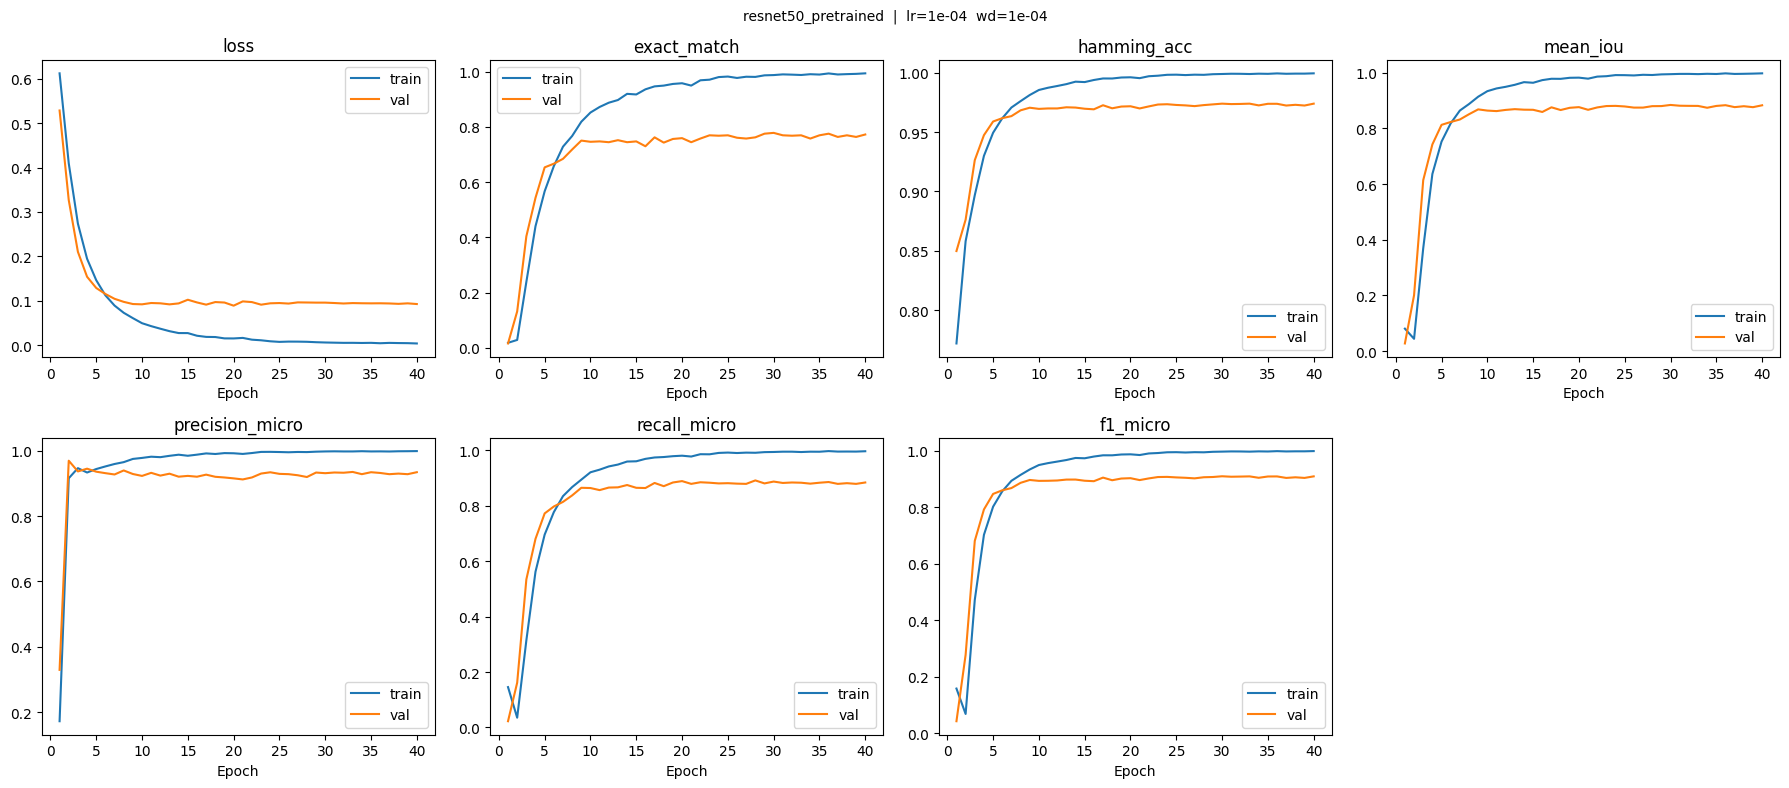

In [5]:
t0 = time.time()
best_state, best_val_f1, history, epochs_run = train_model(
    create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
    lr=best["lr"], weight_decay=best["wd"],
    max_epochs=60, warmup_epochs=5, early_stop_patience=10,
)
training_time = time.time() - t0
print(f"\nBest val F1: {best_val_f1:.4f}  |  Epochs: {epochs_run}  |  Time: {training_time:.1f}s")

save_checkpoint(best_state, MODEL_PATH)
plot_training_history(history, epochs_run, EXPERIMENT_NAME, best["lr"], best["wd"])


## Evaluation

In [6]:
model = load_checkpoint(create_model, NUM_LABELS, MODEL_PATH, DEVICE)
model.eval()

def _predict(images, threshold=0.5):
    with torch.no_grad():
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= threshold).float()
    return preds, probs, logits

val_metrics  = evaluate_predictor(val_loader,  _predict, DEVICE)
test_metrics = evaluate_predictor(test_loader, _predict, DEVICE)

rows = [
    {"split": "val",  **{k: round(val_metrics[k],  4) for k in METRIC_KEYS}},
    {"split": "test", **{k: round(test_metrics[k], 4) for k in METRIC_KEYS}},
]
df = pd.DataFrame(rows).set_index("split")
print(df.to_string())


         loss  exact_match  hamming_acc  mean_iou  precision_micro  recall_micro  f1_micro
split                                                                                     
val    0.0956       0.7783       0.9739    0.8841           0.9318        0.8875    0.9091
test   0.1060       0.7610       0.9715    0.8735           0.9172        0.8841    0.9004


In [7]:

print("\nModel summary:")
print_model_info(create_model(NUM_LABELS))
print(f"Training time : {training_time:.1f}s")



Model summary:
  Total params     :   23,532,620
  Trainable params :   23,532,620  (100.0%)
  Model size       : 89.77 MB  (float32 weights)
Training time : 659.1s
